# Music4All EDA for Recommendation and Generation

This notebook is a cleaned, analysis-oriented EDA over the local `music4all` dataset.

It has two goals:
1. **Data readiness check**: confirm the catalog and key tables are usable.
2. **Pipeline-facing analysis**: summarize user/song behavior patterns that matter for recommendation and downstream song generation.

To keep the story clear, the main results are concentrated in the focused EDA section, and repeated exploratory snippets are marked as legacy reference.

## 1. Data Readiness Check Snapshot

In [1]:
from pathlib import Path
import os
import pandas as pd

DATA_PATH = Path('../music4all')

symlink_target = None
symlink_error = None
if DATA_PATH.is_symlink():
    try:
        symlink_target = os.readlink(DATA_PATH)
    except OSError as e:
        symlink_error = str(e)

path_summary = pd.DataFrame([
    {'metric': 'DATA_PATH', 'value': str(DATA_PATH.resolve())},
    {'metric': 'Exists', 'value': bool(DATA_PATH.exists())},
    {'metric': 'Is symlink', 'value': bool(DATA_PATH.is_symlink())},
    {'metric': 'Symlink target', 'value': symlink_target if symlink_target is not None else ''},
    {'metric': 'Symlink read error', 'value': symlink_error if symlink_error is not None else ''},
])

display(path_summary)

,metric,value
0,DATA_PATH,/Users/itsnotjerryh/Desktop/music4all
1,Exists,True
2,Is symlink,True
3,Symlink target,/Users/itsnotjerryh/Desktop/music4all
4,Symlink read error,


In [2]:
from collections import Counter

file_count = 0
dir_count = 0
total_size = 0
ext_counter = Counter()

for root, dirs, files in os.walk(DATA_PATH):
    dir_count += len(dirs)
    for name in files:
        file_count += 1
        p = Path(root) / name
        try:
            sz = p.stat().st_size
            total_size += sz
        except OSError:
            continue
        ext = p.suffix.lower() if p.suffix else '[no_ext]'
        ext_counter[ext] += 1

avg_size = (total_size / file_count) if file_count else 0

inventory_summary = pd.DataFrame([
    {'metric': 'Total files', 'value': int(file_count)},
    {'metric': 'Total dirs', 'value': int(dir_count)},
    {'metric': 'Total size (GB)', 'value': round(float(total_size / (1024**3)), 2)},
    {'metric': 'Average file size (KB)', 'value': round(float(avg_size / 1024), 2)},
])

ext_df = pd.DataFrame(ext_counter.most_common(20), columns=['extension', 'count'])

display(inventory_summary)
display(ext_df)

,metric,value
0,Total files,218546.00
1,Total dirs,2.00
2,Total size (GB),48.85
3,Average file size (KB),234.39


,extension,count
0,.txt,109270
1,.mp3,109269
2,.csv,6
3,[no_ext],1


In [3]:
largest = []

for root, _, files in os.walk(DATA_PATH):
    for name in files:
        p = Path(root) / name
        try:
            sz = p.stat().st_size
            largest.append((sz, p))
        except OSError:
            continue

largest.sort(reverse=True, key=lambda x: x[0])
largest_df = pd.DataFrame([
    {'size_mb': round(float(sz / (1024**2)), 2), 'file': str(p.relative_to(DATA_PATH))}
    for sz, p in largest[:20]
])

display(largest_df)

,size_mb,file
0,233.90,listening_history.csv
1,10.13,id_metadata.csv
2,6.68,id_information.csv
3,6.19,id_tags.csv
4,4.02,id_genres.csv
5,2.16,id_lang.csv
6,0.46,audios/fXO7aH7NFHfPHUgo.mp3
7,0.46,audios/UV96BARf3ciHwFi6.mp3
8,0.46,audios/EltvFIDOgIJJPsRi.mp3
9,0.46,audios/pRAt7KPOlZHhsI7g.mp3


In [4]:
from collections import defaultdict

zero_byte = 0
dup_basename = defaultdict(int)
long_paths = 0

for root, _, files in os.walk(DATA_PATH):
    for name in files:
        p = Path(root) / name
        dup_basename[name] += 1
        if len(str(p)) > 240:
            long_paths += 1
        try:
            if p.stat().st_size == 0:
                zero_byte += 1
        except OSError:
            pass

duplicates = sorted(((k, v) for k, v in dup_basename.items() if v > 1), key=lambda x: x[1], reverse=True)

quality_summary = pd.DataFrame([
    {'metric': 'Zero-byte files', 'value': int(zero_byte)},
    {'metric': 'Paths >240 chars', 'value': int(long_paths)},
    {'metric': 'Duplicate basenames', 'value': int(len(duplicates))},
])

dup_df = pd.DataFrame([
    {
        'basename': name.encode('utf-8', errors='replace').decode('utf-8'),
        'count': int(cnt),
    }
    for name, cnt in duplicates[:20]
])

display(quality_summary)
display(dup_df)

,metric,value
0,Zero-byte files,0
1,Paths >240 chars,0
2,Duplicate basenames,0


""


In [5]:
import random
from datetime import datetime

audio_exts = {'.mp3', '.wav', '.flac', '.m4a', '.aac', '.ogg'}
audio_files = []

for root, _, files in os.walk(DATA_PATH):
    for name in files:
        p = Path(root) / name
        if p.suffix.lower() in audio_exts:
            audio_files.append(p)

sample_n = min(5, len(audio_files))

sample_summary = pd.DataFrame([
    {'metric': 'Found audio files', 'value': int(len(audio_files))},
    {'metric': 'Random sample size', 'value': int(sample_n)},
])

sample_rows = []
for p in random.sample(audio_files, sample_n) if sample_n else []:
    st = p.stat()
    sample_rows.append({
        'file': str(p.relative_to(DATA_PATH)),
        'size_mb': round(float(st.st_size / (1024**2)), 3),
        'modified': datetime.fromtimestamp(st.st_mtime).isoformat(timespec='seconds'),
    })

sample_df = pd.DataFrame(sample_rows)

display(sample_summary)
display(sample_df)

,metric,value
0,Found audio files,109269
1,Random sample size,5


,file,size_mb,modified
0,audios/qpA9JBX814AD0ffA.mp3,0.459,2019-12-04T19:37:10
1,audios/G4Z13wojt7OYNqCk.mp3,0.458,2019-12-04T19:53:53
2,audios/deZF5QKSgSQutYHw.mp3,0.458,2019-12-04T19:20:46
3,audios/xNzd88P4j4NBC6mO.mp3,0.458,2019-12-04T19:11:27
4,audios/4bDv64gElqafsmKx.mp3,0.458,2019-12-04T19:15:14


In [6]:
DATA_PATH = Path('../music4all')

key_csvs = [
    'listening_history.csv',
    'id_metadata.csv',
    'id_information.csv',
    'id_tags.csv',
    'id_genres.csv',
    'id_lang.csv',
]

rows = []
for name in key_csvs:
    p = DATA_PATH / name
    exists = p.exists()
    size_mb = p.stat().st_size / (1024**2) if exists else None
    rows.append({'file': name, 'exists': exists, 'size_mb': round(size_mb, 2) if size_mb is not None else None})

pd.DataFrame(rows)

,file,exists,size_mb
0,listening_history.csv,True,233.90
1,id_metadata.csv,True,10.13
2,id_information.csv,True,6.68
3,id_tags.csv,True,6.19
4,id_genres.csv,True,4.02
5,id_lang.csv,True,2.16


## 2. Dataset Context and Scope

### Dataset snapshot
We use the local **Music4All** dataset (mounted via symlink at `../music4all`).
Current scan confirms:
- **109,269** audio clips and songs (`.mp3`),
- key tables available: `listening_history.csv`, `id_metadata.csv`, `id_information.csv`, `id_tags.csv`, `id_genres.csv`, `id_lang.csv`.

### EDA objective in this notebook
The focused EDA section below is designed to answer:
- how strong the user/song long-tail is,
- what temporal behavior exists in listening logs,
- how complex metadata space is (genre/tag/lang cardinality),
- how heavy and light listeners differ and what that implies for modeling.

In [7]:
def load_tsv_like(csv_path, sample_rows=50000):
    with open(csv_path, 'r', encoding='utf-8', errors='replace') as f:
        header = f.readline().rstrip('\n\r')

        # Detect whether separator is real tab or literal "\\t"
        if '\t' in header:
            sep = '\t'
            sep_name = 'tab'
        elif '\\t' in header:
            sep = '\\t'
            sep_name = 'literal_\\t'
        else:
            sep = ','
            sep_name = 'comma'

        cols = header.split(sep)

        records = []
        for i, line in enumerate(f):
            if i >= sample_rows:
                break
            parts = line.rstrip('\n\r').split(sep)
            if len(parts) < len(cols):
                parts += [None] * (len(cols) - len(parts))
            elif len(parts) > len(cols):
                parts = parts[:len(cols)-1] + [sep.join(parts[len(cols)-1:])]
            records.append(parts)

    df = pd.DataFrame(records, columns=cols)
    return df, sep_name


def quick_profile(csv_path, sample_rows=50000):
    df, sep_used = load_tsv_like(csv_path, sample_rows=sample_rows)
    info = {
        'file': csv_path.name,
        'sep_used': sep_used,
        'sample_rows_loaded': len(df),
        'num_columns': df.shape[1],
        'columns': list(df.columns)
    }
    missing = (df.isna().mean() * 100).sort_values(ascending=False)
    return df, info, missing

profiles = {}
profile_rows = []
missing_tables = {}
errors = []

for name in ['id_metadata.csv', 'id_information.csv', 'id_tags.csv', 'id_genres.csv', 'id_lang.csv']:
    p = DATA_PATH / name
    if p.exists():
        try:
            df, info, missing = quick_profile(p)
            profiles[name] = {'df': df, 'info': info, 'missing': missing}
            profile_rows.append({
                'file': name,
                'sep_used': info['sep_used'],
                'sample_rows_loaded': int(info['sample_rows_loaded']),
                'num_columns': int(info['num_columns']),
                'columns_preview': ', '.join(info['columns'][:12]) + (' ...' if len(info['columns']) > 12 else ''),
            })
            missing_tables[name] = missing.head(10).round(2).rename('missing_pct').to_frame()
        except Exception as e:
            errors.append({'file': name, 'error': str(e)})

profile_df = pd.DataFrame(profile_rows)
error_df = pd.DataFrame(errors)

display(profile_df)
for file_name, missing_df in missing_tables.items():
    display(pd.DataFrame([{'file': file_name}]))
    display(missing_df)
if not error_df.empty:
    display(error_df)

,file,sep_used,sample_rows_loaded,num_columns,columns_preview
0,id_metadata.csv,tab,50000,11,"id, spotify_id, popularity, release, danceabil..."
1,id_information.csv,tab,50000,4,"id, artist, song, album_name"
2,id_tags.csv,tab,50000,2,"id, tags"
3,id_genres.csv,tab,50000,2,"id, genres"
4,id_lang.csv,tab,50000,2,"id, lang"


,file
0,id_metadata.csv


,missing_pct
id,0.0
spotify_id,0.0
popularity,0.0
release,0.0
danceability,0.0
energy,0.0
key,0.0
mode,0.0
valence,0.0
tempo,0.0


,file
0,id_information.csv


,missing_pct
id,0.0
artist,0.0
song,0.0
album_name,0.0


...

,missing_pct
id,0.0
tags,0.0


,file
0,id_genres.csv


,missing_pct
id,0.0
genres,0.0


,file
0,id_lang.csv


,missing_pct
id,0.0
lang,0.0


## 3. Song-Level EDA

This section focuses on song-side structure:
- song popularity and long-tail pattern,
- genre / tag / language composition.

These analyses describe catalog exposure imbalance and metadata complexity before moving to user-level behavior.

In [8]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='talk')

DATA_PATH = Path('../music4all')


def read_auto_sep(path, usecols=None, nrows=None):
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        header = f.readline()
    if '\t' in header:
        sep = '\t'
    elif '\\t' in header:
        sep = '\\t'
    else:
        sep = ','
    return pd.read_csv(path, sep=sep, usecols=usecols, nrows=nrows, engine='python', on_bad_lines='skip')


# You can set MAX_ROWS=None to read all listening logs
MAX_ROWS = 1_500_000

lh = read_auto_sep(DATA_PATH / 'listening_history.csv', usecols=['user', 'song', 'timestamp'], nrows=MAX_ROWS)
lh['timestamp'] = pd.to_datetime(lh['timestamp'], errors='coerce')
lh = lh.dropna(subset=['user', 'song', 'timestamp'])

id_genres = read_auto_sep(DATA_PATH / 'id_genres.csv', usecols=['id', 'genres'])
id_tags = read_auto_sep(DATA_PATH / 'id_tags.csv', usecols=['id', 'tags'])
id_lang = read_auto_sep(DATA_PATH / 'id_lang.csv', usecols=['id', 'lang'])

setup_summary = pd.DataFrame([
    {'metric': 'listening_history shape', 'value': str(lh.shape)},
    {'metric': 'id_genres shape', 'value': str(id_genres.shape)},
    {'metric': 'id_tags shape', 'value': str(id_tags.shape)},
    {'metric': 'id_lang shape', 'value': str(id_lang.shape)},
    {'metric': 'time range', 'value': f"{lh['timestamp'].min()} -> {lh['timestamp'].max()}"},
])

display(setup_summary)

,metric,value
0,listening_history shape,"(1500000, 3)"
1,id_genres shape,"(109269, 2)"
2,id_tags shape,"(109269, 2)"
3,id_lang shape,"(109269, 2)"
4,time range,2013-12-30 22:42:00 -> 2019-03-26 04:23:00


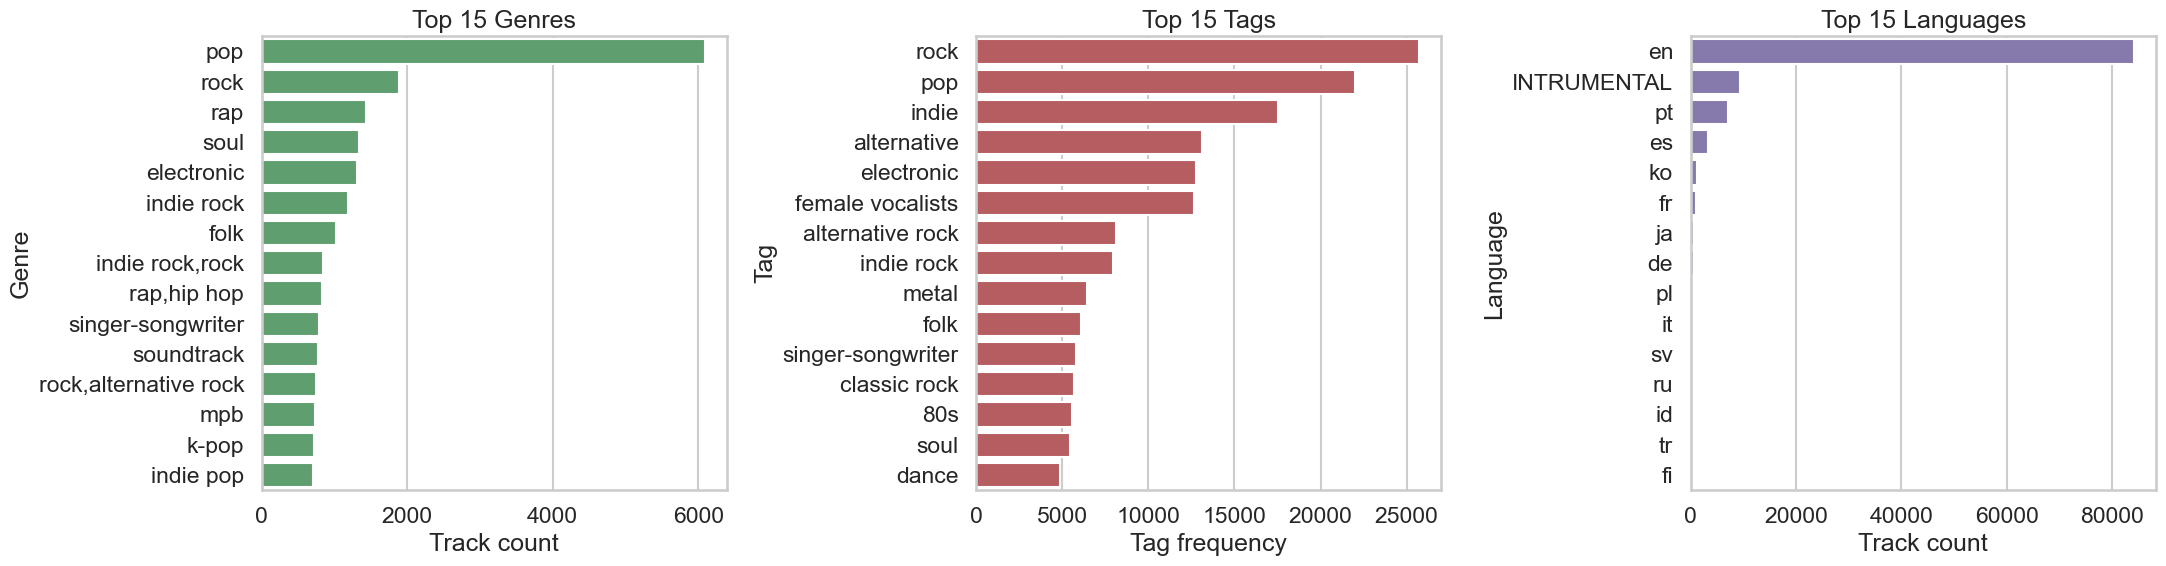

,metric,value
0,unique_genres,23520
1,unique_tags,19507
2,unique_languages,46


,top_genres,genre_count
0,pop,6092
1,rock,1887
2,rap,1431
3,soul,1337
4,electronic,1305
5,indie rock,1182
6,folk,1017
7,"indie rock,rock",840
8,"rap,hip hop",834
9,singer-songwriter,794


,top_tags,tag_count
0,rock,25733
1,pop,22016
2,indie,17539
3,alternative,13114
4,electronic,12773
5,female vocalists,12639
6,alternative rock,8103
7,indie rock,7944
8,metal,6459
9,folk,6106


,top_lang,lang_count
0,en,84103
1,INTRUMENTAL,9417
2,pt,7020
3,es,3225
4,ko,1145
5,fr,994
6,ja,615
7,de,577
8,pl,446
9,it,437


In [10]:
# 3.2 Genre / Tags / Language distribution

genre_counts = id_genres['genres'].fillna('unknown').astype(str).str.strip().replace('', 'unknown').value_counts()
lang_counts = id_lang['lang'].fillna('unknown').astype(str).str.strip().replace('', 'unknown').value_counts()

# tags are multi-label, split by comma
raw_tags = id_tags['tags'].fillna('').astype(str)
tag_series = raw_tags.str.split(',').explode().astype(str).str.strip().str.lower()
tag_series = tag_series[tag_series.ne('')]
tag_counts = tag_series.value_counts()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(x=genre_counts.head(15).values, y=genre_counts.head(15).index, ax=axes[0], color='#55A868')
axes[0].set_title('Top 15 Genres')
axes[0].set_xlabel('Track count')
axes[0].set_ylabel('Genre')

sns.barplot(x=tag_counts.head(15).values, y=tag_counts.head(15).index, ax=axes[1], color='#C44E52')
axes[1].set_title('Top 15 Tags')
axes[1].set_xlabel('Tag frequency')
axes[1].set_ylabel('Tag')

sns.barplot(x=lang_counts.head(15).values, y=lang_counts.head(15).index, ax=axes[2], color='#8172B3')
axes[2].set_title('Top 15 Languages')
axes[2].set_xlabel('Track count')
axes[2].set_ylabel('Language')

plt.tight_layout()
plt.show()

metadata_summary = pd.DataFrame([
    {'metric': 'unique_genres', 'value': int(genre_counts.shape[0])},
    {'metric': 'unique_tags', 'value': int(tag_counts.shape[0])},
    {'metric': 'unique_languages', 'value': int(lang_counts.shape[0])},
])

display(metadata_summary)

display(pd.DataFrame({
    'top_genres': genre_counts.head(10).index,
    'genre_count': genre_counts.head(10).values
}))
display(pd.DataFrame({
    'top_tags': tag_counts.head(10).index,
    'tag_count': tag_counts.head(10).values
}))
display(pd.DataFrame({
    'top_lang': lang_counts.head(10).index,
    'lang_count': lang_counts.head(10).values
}))

### Analysis Placeholder: Genre / Tag / Language Distribution

- **What this figure/table suggests:**
- 

- **Potential explanation:**
- 

- **Implication for recommendation / generation pipeline:**
- 

- **Decision or follow-up check:**
- 

## 4. User-Level EDA

This section summarizes user-side behavior:
- how many users are observed,
- how interactions are distributed across users,
- how concentrated heavy-user behavior is.

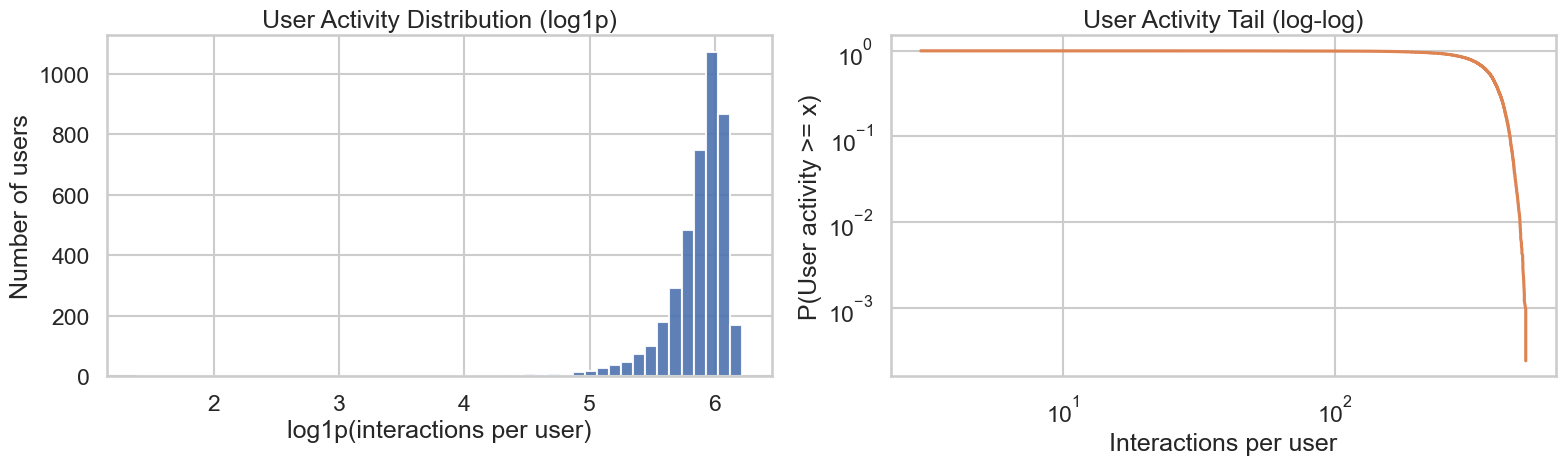

,metric,value
0,unique_users,4166
1,median_interactions_per_user,374
2,p90_interactions_per_user,437
3,p99_interactions_per_user,476
4,min_interactions_per_user,3
5,max_interactions_per_user,500


,interactions
user,
user_Gw6JYbhy,500
user_CiXkCe5G,500
user_HQe3fwTy,500
user_F4xk4WW8,500
user_2yPi90hx,494
user_8oLXB0CK,494
user_2CsnB2wx,493
user_Au6lS4dy,492
user_Aq0uoHiU,491


In [11]:
# 4.1 User listening-count distribution
user_counts = lh.groupby('user').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(np.log1p(user_counts.values), bins=50, color='#4C72B0', alpha=0.9)
axes[0].set_title('User Activity Distribution (log1p)')
axes[0].set_xlabel('log1p(interactions per user)')
axes[0].set_ylabel('Number of users')

# CCDF-like curve to show heavy tail
sorted_counts = np.sort(user_counts.values)[::-1]
ccdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[1].plot(sorted_counts, ccdf, color='#DD8452')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('User Activity Tail (log-log)')
axes[1].set_xlabel('Interactions per user')
axes[1].set_ylabel('P(User activity >= x)')

plt.tight_layout()
plt.show()

user_summary = pd.DataFrame([
    {'metric': 'unique_users', 'value': int(user_counts.shape[0])},
    {'metric': 'median_interactions_per_user', 'value': int(user_counts.median())},
    {'metric': 'p90_interactions_per_user', 'value': int(user_counts.quantile(0.9))},
    {'metric': 'p99_interactions_per_user', 'value': int(user_counts.quantile(0.99))},
    {'metric': 'min_interactions_per_user', 'value': int(user_counts.min())},
    {'metric': 'max_interactions_per_user', 'value': int(user_counts.max())}
])

display(user_summary)
display(user_counts.head(15).rename('interactions').to_frame())


### Analysis Placeholder: User Listening-Count Distribution

- **What this figure/table suggests:**
- 

- **Potential explanation:**
- 

- **Implication for recommendation / generation pipeline:**
- 

- **Decision or follow-up check:**
- 

## 5. User + Song Interaction EDA

This section combines user and song behavior to inspect interaction dynamics:
- temporal interaction patterns,
- profile differences between heavy and light listener groups,
- interaction-derived signals useful for recommendation and generation evaluation.

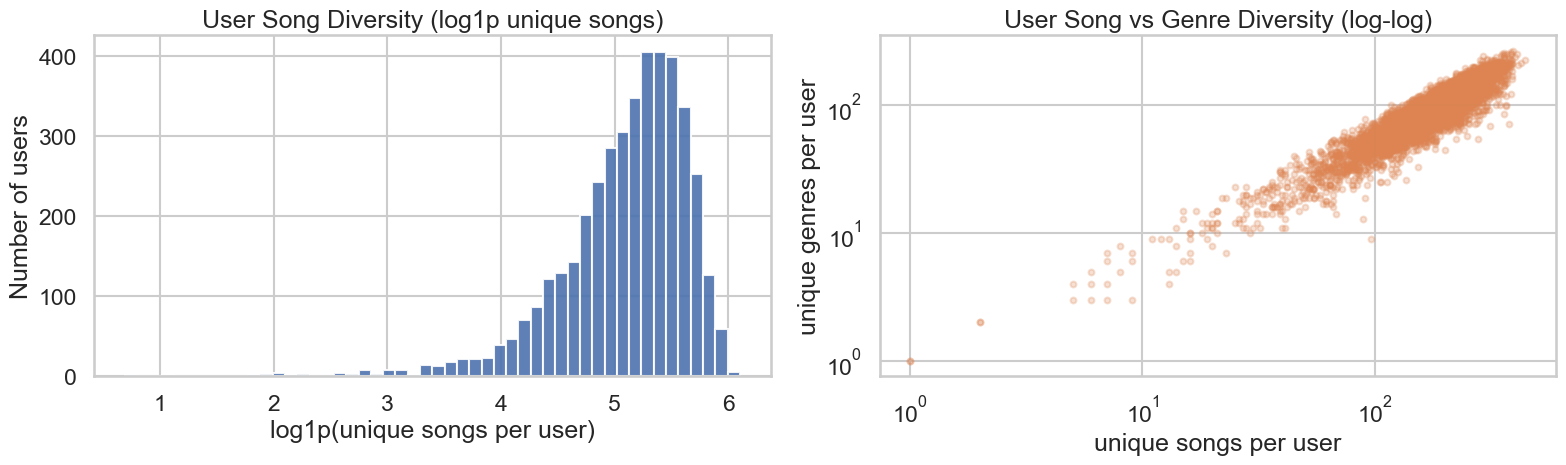

,metric,value
0,users_in_merged_profile,4166
1,median_unique_songs_per_user,181
2,median_unique_genres_per_user,92
3,median_unique_langs_per_user,4


,user,n_interactions,n_unique_songs,n_unique_genres,n_unique_langs
0,user_007XIjOr,440,160,97,3
1,user_00Y0Uqn9,399,149,83,4
2,user_00c8xHqc,391,150,86,3
3,user_00qujrxB,403,289,181,4
4,user_00s56GJz,386,204,132,4
5,user_019SS48x,423,148,91,2
6,user_01TB3qzT,386,218,121,4
7,user_01iQLLO6,481,277,147,3
8,user_01kaIjH9,382,249,84,9
9,user_01vPMYvi,432,54,26,3


In [12]:
# 5.0 User + Song merged profile (interaction-enriched view)

lh_merge = lh.rename(columns={'song': 'song_id'}).copy()

genre_map = id_genres.rename(columns={'id': 'song_id'}).copy()
lang_map = id_lang.rename(columns={'id': 'song_id'}).copy()

merged = lh_merge.merge(genre_map[['song_id', 'genres']], on='song_id', how='left')
merged = merged.merge(lang_map[['song_id', 'lang']], on='song_id', how='left')

merged['genres'] = merged['genres'].fillna('unknown').astype(str).str.strip().replace('', 'unknown')
merged['lang'] = merged['lang'].fillna('unknown').astype(str).str.strip().replace('', 'unknown')

user_song_profile = merged.groupby('user').agg(
    n_interactions=('song_id', 'size'),
    n_unique_songs=('song_id', 'nunique'),
    n_unique_genres=('genres', 'nunique'),
    n_unique_langs=('lang', 'nunique'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(np.log1p(user_song_profile['n_unique_songs']), bins=50, color='#4C72B0', alpha=0.9)
axes[0].set_title('User Song Diversity (log1p unique songs)')
axes[0].set_xlabel('log1p(unique songs per user)')
axes[0].set_ylabel('Number of users')

sample_profile = user_song_profile.sample(min(len(user_song_profile), 20000), random_state=42)
axes[1].scatter(
    sample_profile['n_unique_songs'],
    sample_profile['n_unique_genres'],
    alpha=0.25,
    s=18,
    color='#DD8452'
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('User Song vs Genre Diversity (log-log)')
axes[1].set_xlabel('unique songs per user')
axes[1].set_ylabel('unique genres per user')

plt.tight_layout()
plt.show()

user_song_summary = pd.DataFrame([
    {'metric': 'users_in_merged_profile', 'value': int(user_song_profile.shape[0])},
    {'metric': 'median_unique_songs_per_user', 'value': int(user_song_profile['n_unique_songs'].median())},
    {'metric': 'median_unique_genres_per_user', 'value': int(user_song_profile['n_unique_genres'].median())},
    {'metric': 'median_unique_langs_per_user', 'value': int(user_song_profile['n_unique_langs'].median())},
])

display(user_song_summary)
display(user_song_profile.head(15))

### Analysis Placeholder: User + Song Merged Profile

- **What this figure/table suggests:**
- 

- **Potential explanation:**
- 

- **Implication for recommendation / generation pipeline:**
- 

- **Decision or follow-up check:**
- 

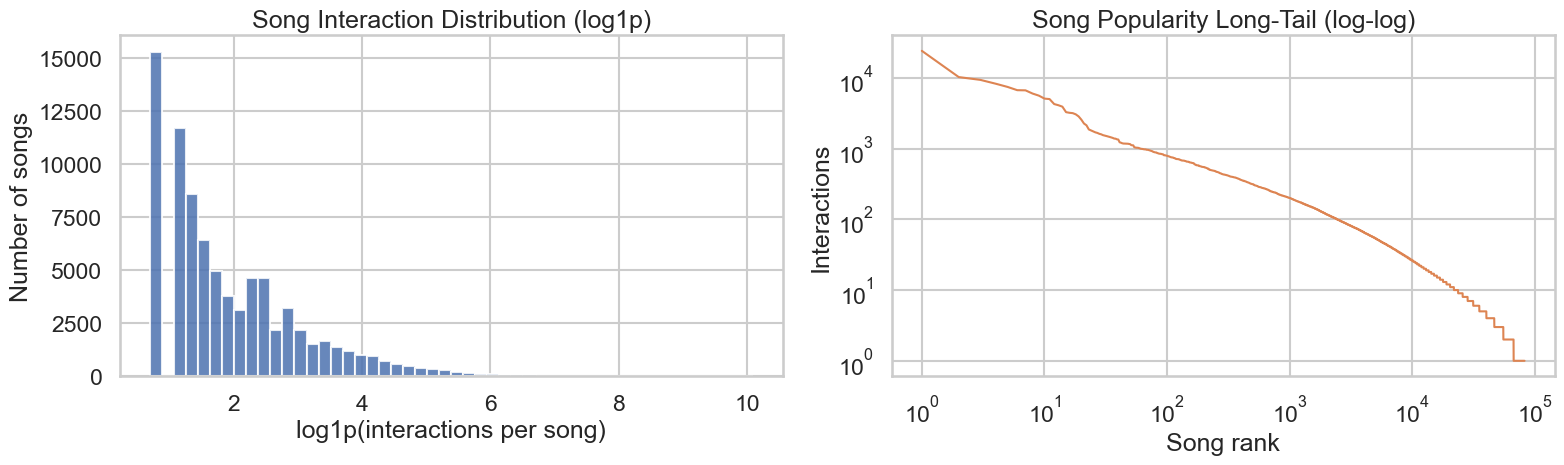

,metric,value
0,unique_songs_in_logs,82161
1,median_interactions_per_song,4
2,p90_interactions_per_song,32


,interactions
song,
32m5suoC94ytD8Ed,24033
YwURIu6eZDCJyuEf,10229
vkOg9ZAiUgUT87k6,9341
7Gsb7yKtAJNCvWez,8245
KKmk2QJLVj2Aqsjg,7426
8LgQbYbM6Vz2my0y,6678
Pf7CTDMAqnLhbcY2,6644
3shrACNQQ5eeQEAO,5983
xMkeAOwn6AzEeYGh,5592


In [16]:
# 3.1 Song distribution: popularity + long-tail
song_counts = lh.groupby('song').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram of interactions per song (log scale on x)
axes[0].hist(np.log1p(song_counts.values), bins=50, color='#4C72B0', alpha=0.85)
axes[0].set_title('Song Interaction Distribution (log1p)')
axes[0].set_xlabel('log1p(interactions per song)')
axes[0].set_ylabel('Number of songs')

# Right: rank-frequency (long tail)
ranks = np.arange(1, len(song_counts) + 1)
axes[1].plot(ranks, song_counts.values, color='#DD8452', linewidth=1.5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Song Popularity Long-Tail (log-log)')
axes[1].set_xlabel('Song rank')
axes[1].set_ylabel('Interactions')

plt.tight_layout()
plt.show()

song_summary = pd.DataFrame([
    {'metric': 'unique_songs_in_logs', 'value': int(song_counts.shape[0])},
    {'metric': 'median_interactions_per_song', 'value': int(song_counts.median())},
    {'metric': 'p90_interactions_per_song', 'value': int(song_counts.quantile(0.9))},
])

display(song_summary)
display(song_counts.head(15).rename('interactions').to_frame())

### Analysis Placeholder: Song Popularity and Long-Tail

- **What this figure/table suggests:**
- 

- **Potential explanation:**
- 

- **Implication for recommendation / generation pipeline:**
- 

- **Decision or follow-up check:**
- 

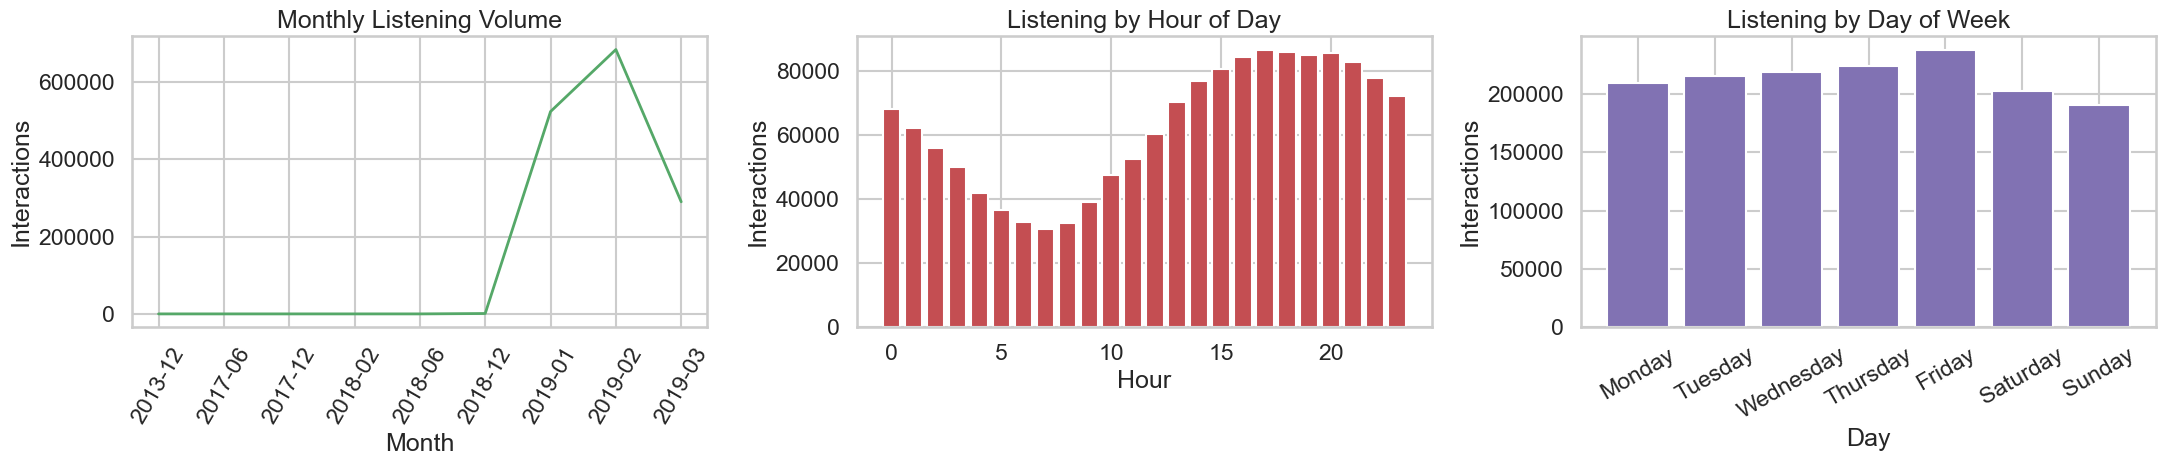

,metric,value
0,observed_date_span,2013-12-30 22:42:00 -> 2019-03-26 04:23:00
1,number_of_distinct_dates,114


In [13]:
# 5.1 User + Song interaction time distribution
lh_time = lh.copy()
lh_time['date'] = lh_time['timestamp'].dt.date
lh_time['month'] = lh_time['timestamp'].dt.to_period('M').astype(str)
lh_time['hour'] = lh_time['timestamp'].dt.hour
lh_time['dow'] = lh_time['timestamp'].dt.day_name()

monthly = lh_time.groupby('month').size()
hourly = lh_time.groupby('hour').size().reindex(range(24), fill_value=0)
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = lh_time['dow'].value_counts().reindex(dow_order).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

axes[0].plot(monthly.index, monthly.values, color='#55A868', linewidth=2)
axes[0].set_title('Monthly Listening Volume')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Interactions')
axes[0].tick_params(axis='x', rotation=60)

axes[1].bar(hourly.index, hourly.values, color='#C44E52')
axes[1].set_title('Listening by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Interactions')

axes[2].bar(dow_counts.index, dow_counts.values, color='#8172B3')
axes[2].set_title('Listening by Day of Week')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Interactions')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

time_summary = pd.DataFrame([
    {'metric': 'observed_date_span', 'value': f"{lh_time['timestamp'].min()} -> {lh_time['timestamp'].max()}"},
    {'metric': 'number_of_distinct_dates', 'value': int(lh_time['date'].nunique())},
])

display(time_summary)

### Analysis Placeholder: User + Song Interaction Time Distribution

- **What this figure/table suggests:**
- 

- **Potential explanation:**
- 

- **Implication for recommendation / generation pipeline:**
- 

- **Decision or follow-up check:**
- 

/var/folders/28/1r050w4j7j5c4jn87rdsh2hw0000gn/T/ipykernel_41792/138446831.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=compare, x='group', y='span_days', ax=axes[0], palette={'light':'#64B5CD', 'heavy':'#E17C73'})


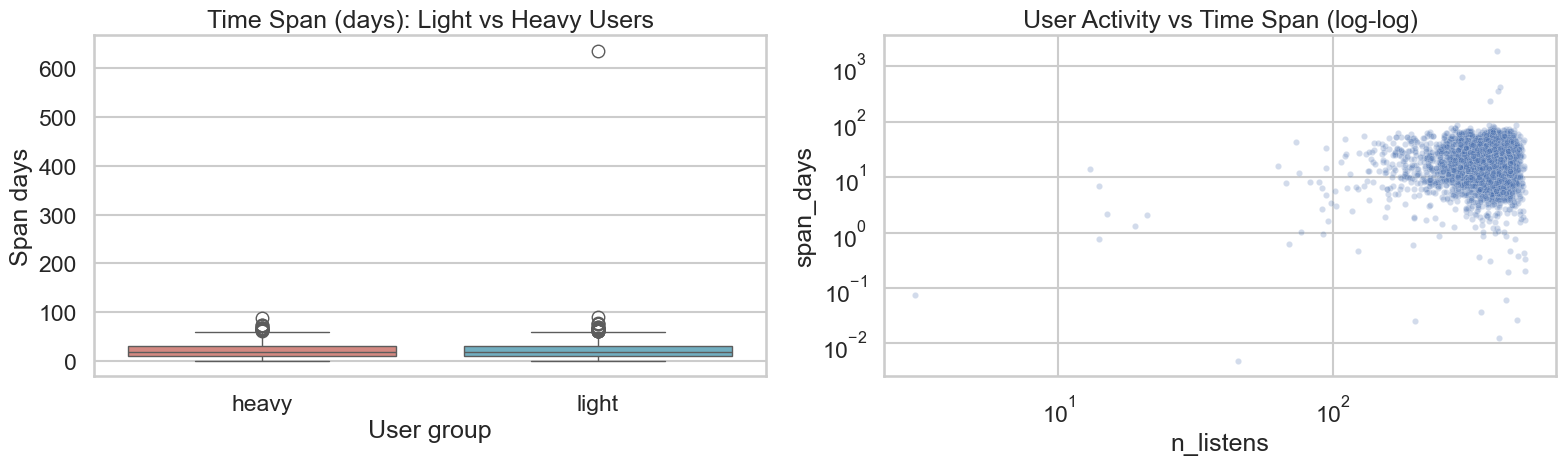

,metric,value
0,light_threshold_q20,309.0
1,heavy_threshold_q80,419.0


,users,median_listens,median_span_days,p90_span_days,median_unique_songs
group,,,,,
heavy,835,437.0,18.18,43.09,203.0
light,838,266.0,17.59,46.35,117.0


,metric,value
0,light_users_span_ge_30_days,209 / 838
1,light_users_span_ge_90_days,1 / 838


In [14]:
# 5.2 User + Song profile (heavy vs light listeners + temporal span)
user_profile = lh.groupby('user').agg(
    n_listens=('song', 'size'),
    first_ts=('timestamp', 'min'),
    last_ts=('timestamp', 'max'),
    n_unique_songs=('song', 'nunique')
).reset_index()

user_profile['span_days'] = (user_profile['last_ts'] - user_profile['first_ts']).dt.total_seconds() / 86400.0

q20 = user_profile['n_listens'].quantile(0.2)
q80 = user_profile['n_listens'].quantile(0.8)

user_profile['group'] = 'mid'
user_profile.loc[user_profile['n_listens'] <= q20, 'group'] = 'light'
user_profile.loc[user_profile['n_listens'] >= q80, 'group'] = 'heavy'

compare = user_profile[user_profile['group'].isin(['light', 'heavy'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=compare, x='group', y='span_days', ax=axes[0], palette={'light':'#64B5CD', 'heavy':'#E17C73'})
axes[0].set_title('Time Span (days): Light vs Heavy Users')
axes[0].set_xlabel('User group')
axes[0].set_ylabel('Span days')

sns.scatterplot(
    data=user_profile.sample(min(len(user_profile), 20000), random_state=42),
    x='n_listens', y='span_days', alpha=0.25, s=20, ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('User Activity vs Time Span (log-log)')
axes[1].set_xlabel('n_listens')
axes[1].set_ylabel('span_days')

plt.tight_layout()
plt.show()

summary = compare.groupby('group').agg(
    users=('user', 'count'),
    median_listens=('n_listens', 'median'),
    median_span_days=('span_days', 'median'),
    p90_span_days=('span_days', lambda x: x.quantile(0.9)),
    median_unique_songs=('n_unique_songs', 'median')
).round(2)

threshold_summary = pd.DataFrame([
    {'metric': 'light_threshold_q20', 'value': round(float(q20), 2)},
    {'metric': 'heavy_threshold_q80', 'value': round(float(q80), 2)},
])

display(threshold_summary)
display(summary)

light_users = user_profile[user_profile['group'] == 'light']
light_span_summary = pd.DataFrame([
    {
        'metric': 'light_users_span_ge_30_days',
        'value': f"{int((light_users['span_days'] >= 30).sum())} / {len(light_users)}"
    },
    {
        'metric': 'light_users_span_ge_90_days',
        'value': f"{int((light_users['span_days'] >= 90).sum())} / {len(light_users)}"
    },
])

display(light_span_summary)

### Analysis Placeholder: User + Song Profile (Heavy vs Light)

- **What this figure/table suggests:**
- 

- **Potential explanation:**
- 

- **Implication for recommendation / generation pipeline:**
- 

- **Decision or follow-up check:**
- 

## Optional Writing Notes

- Use this space for final cross-section conclusions if needed.